# 小鼠综合分析


In [18]:
# 导入必要的库
import os
from brainnetwork import load_data, preprocess_data, preprocess_spike_data, rr_selection_class
from brainnetwork import classify_by_timepoints, FI_by_timepoints_v2, FI_by_neuron_count
from brainnetwork import construct_correlation_network, compute_network_metrics_by_class
from brainnetwork.visualization import *
# %% 可视化相关函数定义
from tifffile import imread 
import numpy as np
import pandas as pd
import scipy.stats as stats


In [19]:
base_dir = "/beegfs_hdd/data/nfs_share/users/guiyun/nishome/Micedata/"
data_paths = ["M21_1107", "M71_1024", "M73_1128", "M77_1031", "M77_1107", "M78_1017", "M79_1128", "M91_1017"]
idx = 4 # Change this index to select different datasets
data_path = base_dir + data_paths[idx] # 'M77_1031'
print(f"Processing data from: {data_path}")
save_dir = "../results/" + data_paths[idx] 

data_out_dir = os.path.join(save_dir, "data")
fig_out_dir = os.path.join(save_dir, "figures")

os.makedirs(data_out_dir, exist_ok=True)
os.makedirs(fig_out_dir, exist_ok=True)

Processing data from: /beegfs_hdd/data/nfs_share/users/guiyun/nishome/Micedata/M77_1107


基础响应和编码

In [20]:
neuron_data_flo, neuron_pos_flo, start_edges_flo, stimulus_data_flo = load_data(data_path, data_type='fluorescence')
segments_flo, labels_flo, neuron_pos_rr = preprocess_data(
    neuron_data_flo,
    neuron_pos_flo,
    start_edges_flo,
    stimulus_data_flo,
)

原始神经数据形状: (8402, 29086)
使用快速RR筛选算法 (按类分别筛选取并集)...
  - 类别 1 贡献了 202 个 RR 神经元
  - 类别 2 贡献了 186 个 RR 神经元
  - 类别 3 贡献了 183 个 RR 神经元
三类并集后共筛选出 343 个唯一 RR 神经元


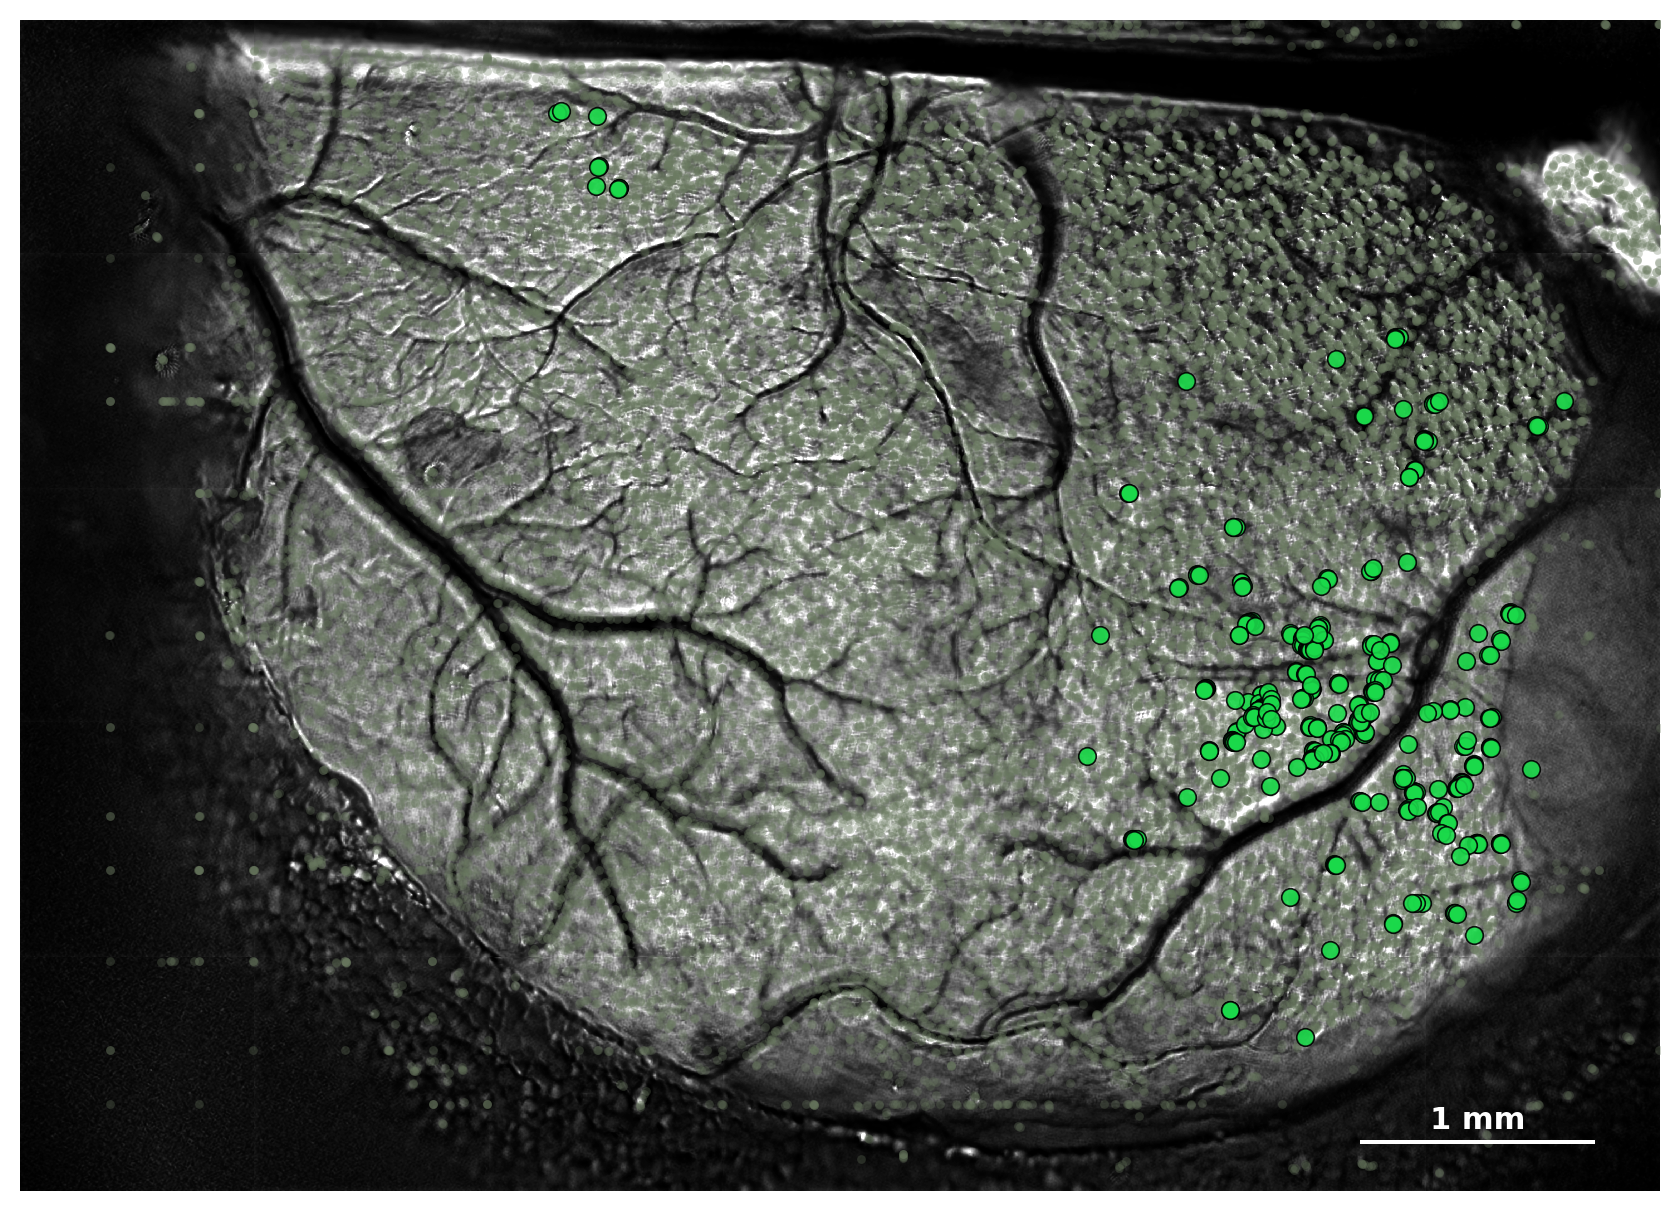

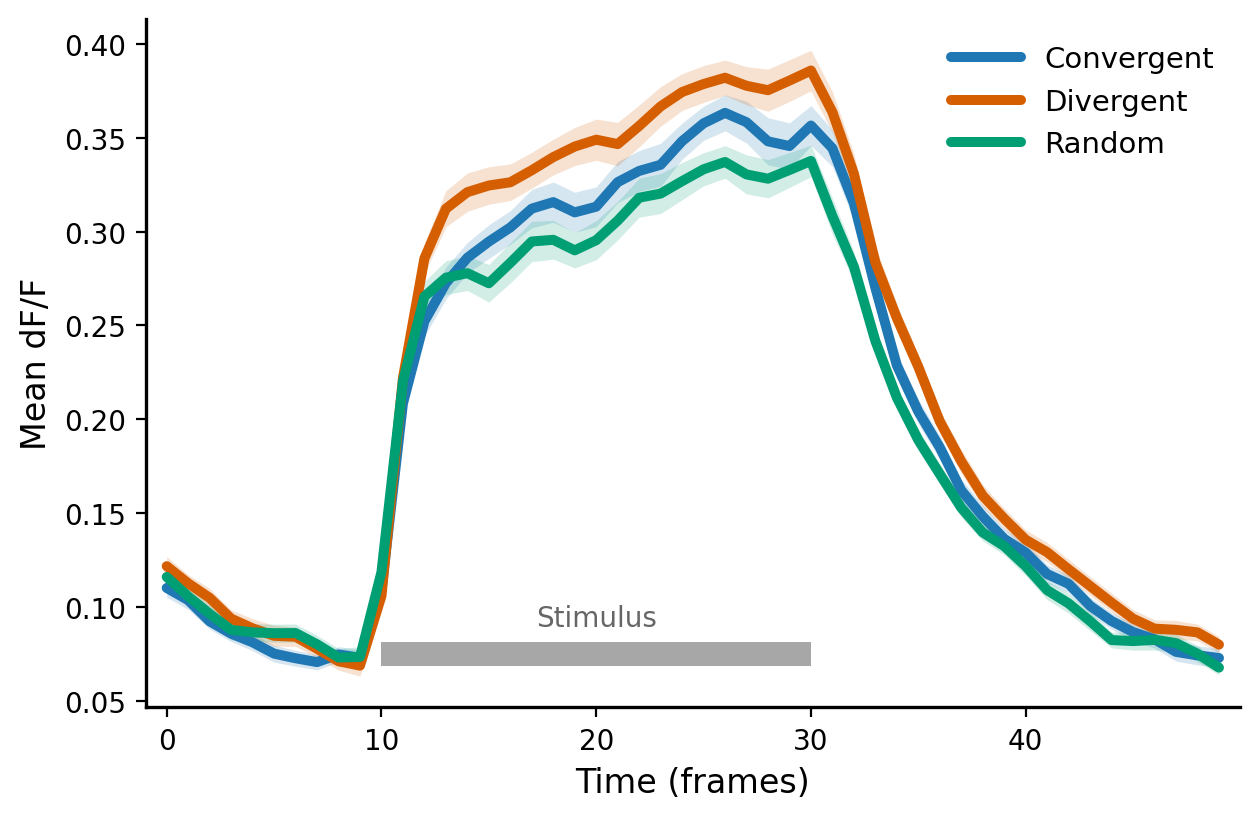

In [21]:
try:
    rr_distribution_plot_pretty(neuron_pos_flo, neuron_pos_rr, data_path, gamma=1.1, fig_out_dir=fig_out_dir)
except Exception as e:
    print(f"Error occurred while plotting RR distribution for spike data: {e}")

plot_rr_population_average_pretty(segments_flo, labels_flo, fig_out_dir=fig_out_dir)

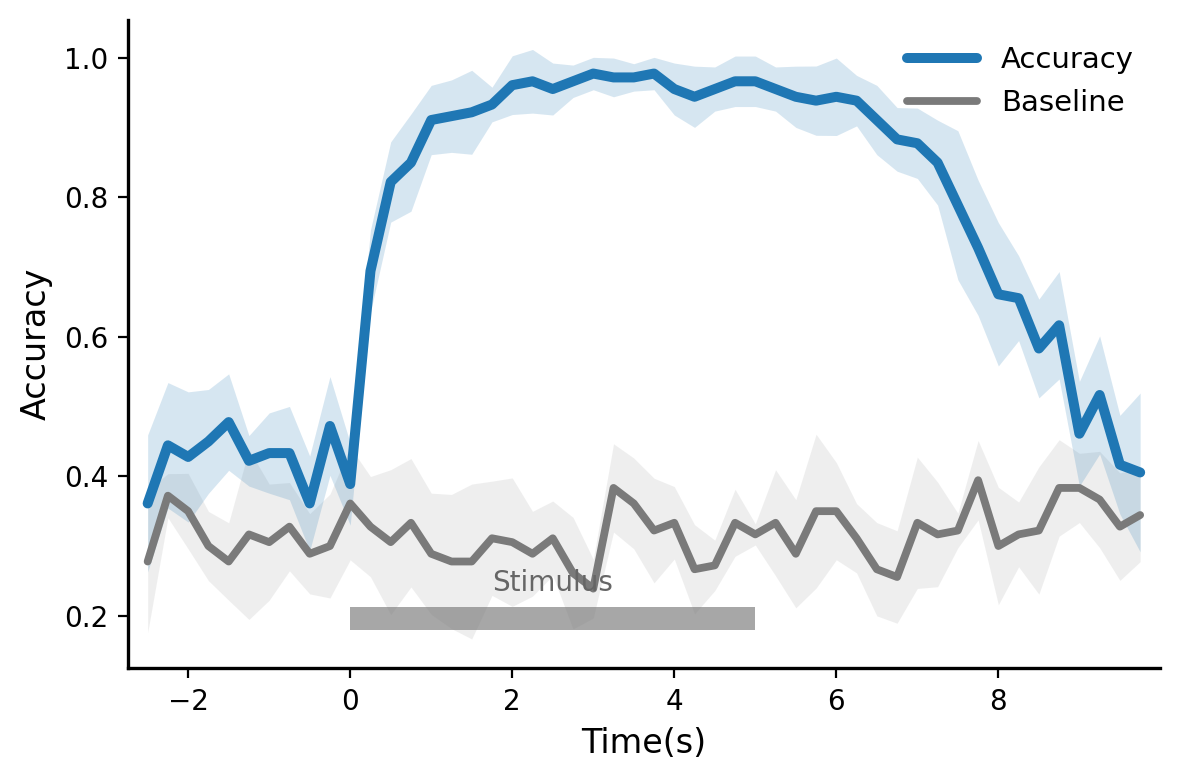

In [22]:
accuracies, time_points, accuracy_std, n_folds = classify_by_timepoints(segments_flo, labels_flo)

# 进行标签随机打乱的分类分析，作为基线比较
labels_shuffled = np.random.permutation(labels_flo)
accuracies_shu, time_points_shu, accuracy_std_shu, n_folds_shu = classify_by_timepoints(segments_flo, labels_shuffled)



plot_accuracy(time_points=time_points, accuracies=accuracies, baseline=accuracies_shu, accuracy_std=accuracy_std, baseline_std=accuracy_std_shu, save_path=os.path.join(fig_out_dir, "classification_accuracy.png"))

In [23]:
neuron_data, neuron_pos, start_edges, stimulus_data = load_data(data_path)
segments_spi, labels_spi, neuron_pos_spi = preprocess_spike_data(
        neuron_data,
        neuron_pos,
        start_edges,
        stimulus_data,
    )

nx_result = compute_network_metrics_by_class(segments_spi, labels_spi, neuron_pos_spi, do_bootstrap=False)

原始神经数据形状: (8402, 28982)
使用快速RR筛选算法 (按类分别筛选取并集)...
  - 类别 1 贡献了 83 个 RR 神经元
  - 类别 2 贡献了 105 个 RR 神经元
  - 类别 3 贡献了 93 个 RR 神经元
三类并集后共筛选出 173 个唯一 RR 神经元


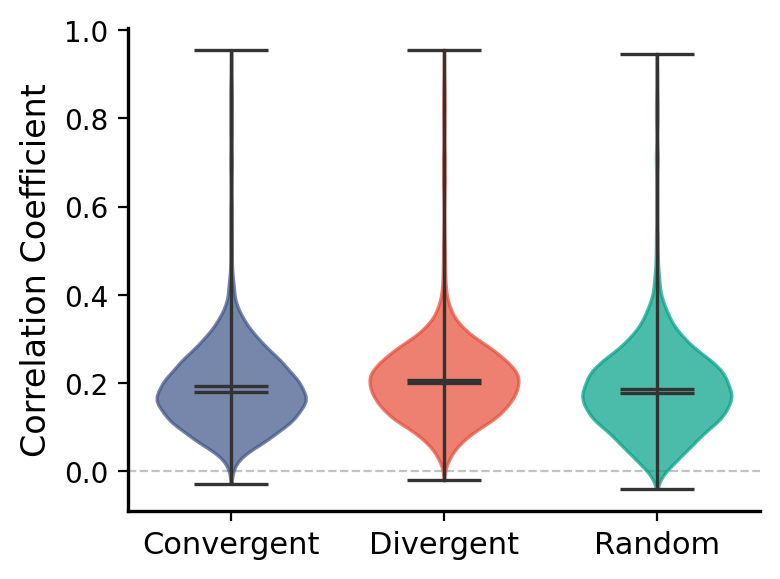

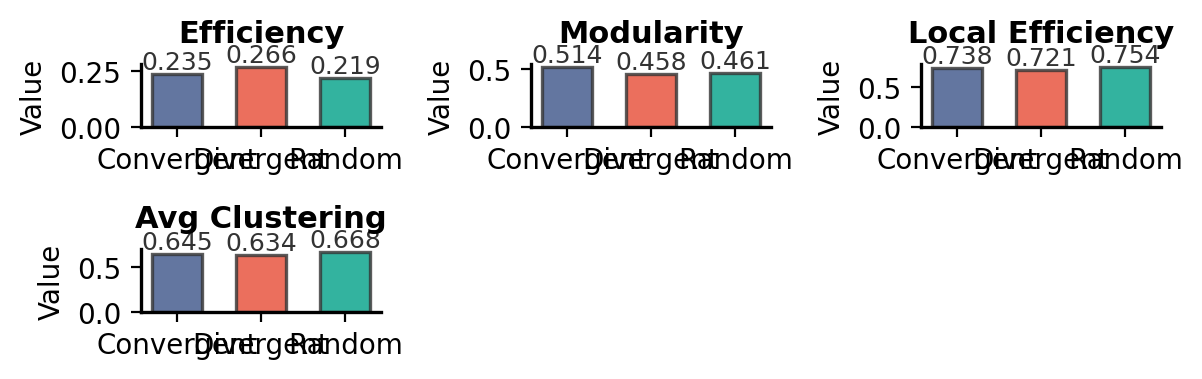

In [24]:
plot_correlation_violin_optim(nx_result, fig_out_dir=fig_out_dir)
plot_network_metrics_bars_optim(nx_result, metrics=['efficiency', 'modularity', 'local_efficiency', 'avg_clustering'], figsize=(6,2), fig_out_dir=fig_out_dir)


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Trial 聚合：计算每个 Trial 的平均活动
# 假设 X_trials 的形状是 (Trial总数, 帧数, 神经元数)
X_trial_averaged = np.mean(segments_spi[:, :, 10:13], axis=2) # 得到 (n_trials, n_neurons)

unique_labels = np.unique(labels_spi)
min_count = min(np.sum(labels_spi == l) for l in unique_labels)

# 2. 平衡数据集
X_balanced_list = []
labels_balanced = []

for label in unique_labels:
    mask = (labels_spi == label)
    X_label = X_trial_averaged[mask]
    
    # 建议：随机采样而非固定取前几个
    indices = np.random.choice(len(X_label), min_count, replace=False)
    X_sampled = X_label[indices]
    
    X_balanced_list.append(X_sampled)
    labels_balanced.extend([label] * min_count)

# 2. 关键修正：将列表转化为单一矩阵 [cite: 1]
X_trial_averaged_balanced = np.vstack(X_balanced_list)
labels_balanced = np.array(labels_balanced)


In [26]:
# 1. Trial 聚合：计算每个 Trial 的平均活动
# 假设 X_trials 的形状是 (Trial总数, 帧数, 神经元数)
X_trial_averaged = np.mean(segments_spi[:, :, 10:13], axis=2) # 得到 (n_trials, n_neurons)

unique_labels = np.unique(labels_spi)
min_count = min(np.sum(labels_spi == l) for l in unique_labels)

# 2. 平衡数据集
X_balanced_list = []
labels_balanced = []

for label in unique_labels:
    mask = (labels_spi == label)
    X_label = X_trial_averaged[mask]
    
    # 建议：随机采样而非固定取前几个
    indices = np.random.choice(len(X_label), min_count, replace=False)
    X_sampled = X_label[indices]
    
    X_balanced_list.append(X_sampled)
    labels_balanced.extend([label] * min_count)

# 2. 关键修正：将列表转化为单一矩阵 [cite: 1]
X_trial_averaged_balanced = np.vstack(X_balanced_list)
labels_balanced = np.array(labels_balanced)


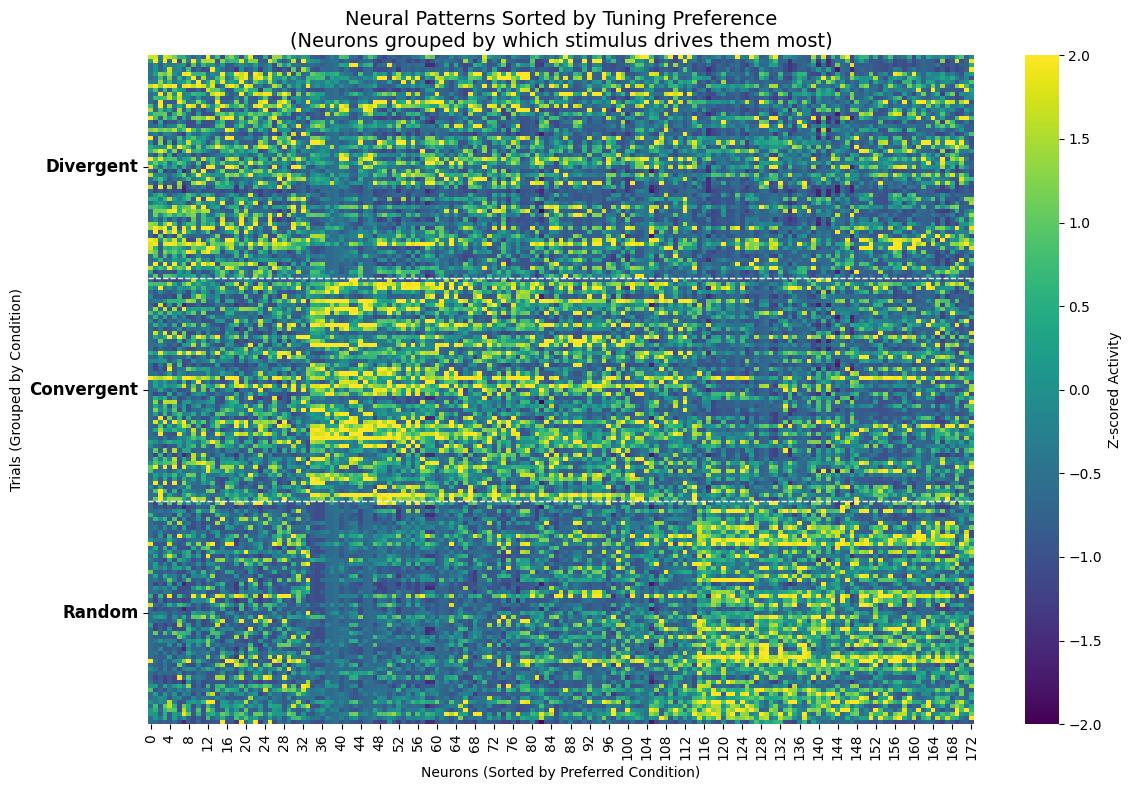

Generating Clustermap (Hierarchical Clustering)...


/beegfs_hdd/data/nfs_share/users/guiyun/nishome/brainnetwork/.venv/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


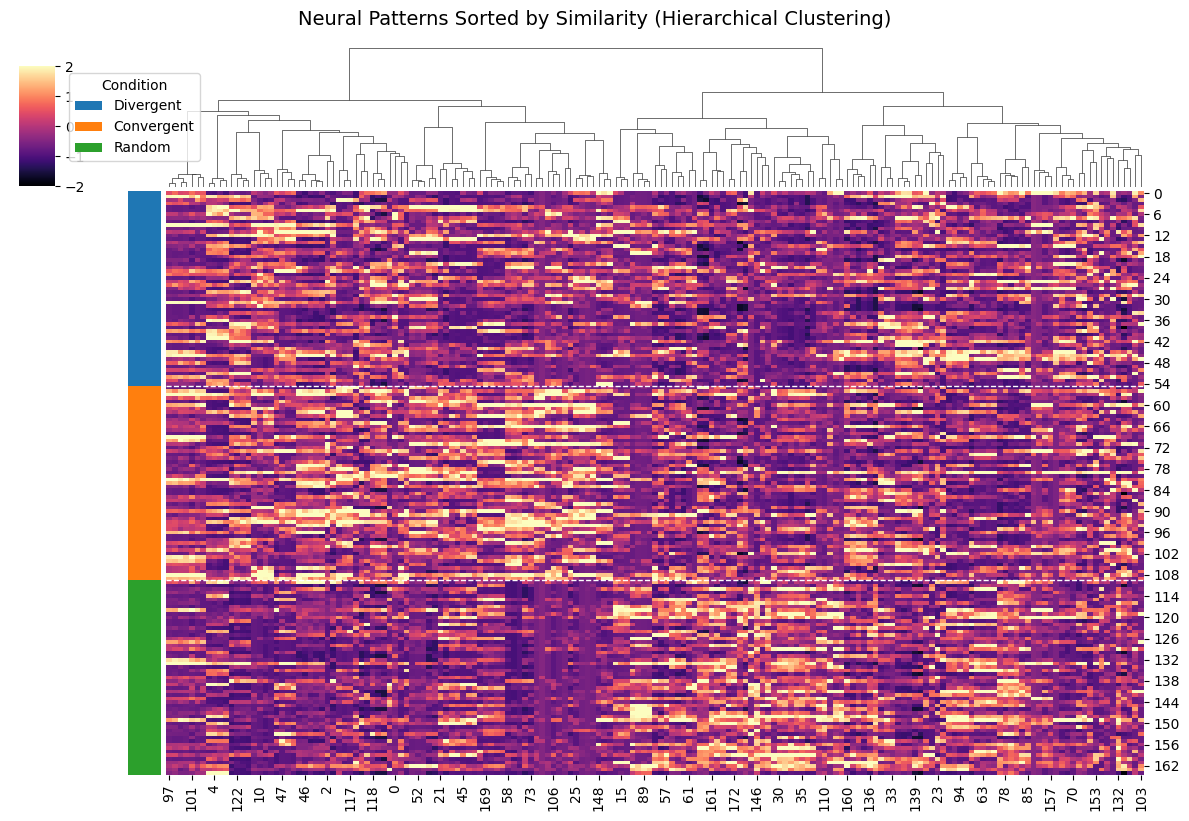

In [27]:
from scipy.stats import zscore

# 定义语义映射
label_names = {1: 'Divergent', 2: 'Convergent', 3: 'Random', 0: 'Resting'}

def plot_sorted_neural_patterns(X, labels, label_map):
    """
    可视化神经元活动热图，通过两种策略对神经元（X轴）进行排序，
    以揭示不同刺激条件（Y轴）下的Pattern差异。
    """
    
    # 1. 数据预处理
    # ------------------------------------------------
    # Z-score 归一化：消除神经元绝对发放率的差异，只看相对变化
    # axis=0 对每一列（神经元）做归一化
    X_norm = zscore(X, axis=0)
    
    # 替换 NaN (如果有些神经元完全不发放，std为0，zscore会产生nan)
    X_norm = np.nan_to_num(X_norm)
    
    unique_labels = np.unique(labels)
    sorted_labels = sorted(unique_labels) # 确保顺序: Divergent, Convergent, Random...
    
    # 获取标签的分界线位置，用于画横线
    label_counts = [np.sum(labels == l) for l in sorted_labels]
    boundaries = np.cumsum(label_counts)[:-1]
    
    # 重新排列 X 的行（Trial），确保它是按 Label 顺序排列的
    # (虽然通常已经是排好的，但为了保险起见)
    trial_sort_idx = np.argsort(labels)
    X_sorted_trials = X_norm[trial_sort_idx]
    labels_sorted = labels[trial_sort_idx]
    
    # ------------------------------------------------
    # 策略一：偏好性排序 (Preference Sorting)
    # ------------------------------------------------
    # 计算每个神经元在各条件下的平均活动
    n_neurons = X.shape[1]
    neuron_means = np.zeros((len(unique_labels), n_neurons))
    
    for i, l in enumerate(sorted_labels):
        # 找到该条件下的所有行
        mask = (labels == l)
        # 计算该条件下每个神经元的均值
        neuron_means[i, :] = np.mean(X_norm[mask], axis=0)
        
    # 找出每个神经元在哪个条件下最强 (Argmax)
    peak_condition_idx = np.argmax(neuron_means, axis=0)
    
    # 在同一个条件下，再按强度排个序，为了视觉更好看
    peak_magnitude = np.max(neuron_means, axis=0)
    
    # 综合排序键值: 先按条件ID排，再按强度排
    # 技巧: use lexsort. Primary key is last argument.
    sort_key = np.lexsort((-peak_magnitude, peak_condition_idx))
    
    X_pref_sorted = X_sorted_trials[:, sort_key]
    
    # ------------------------------------------------
    # 绘图 1: 偏好性排序热图
    # ------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(X_pref_sorted, ax=ax, cmap='viridis', vmin=-2, vmax=2, cbar_kws={'label': 'Z-scored Activity'})
    
    # 画水平线分隔不同条件
    for b in boundaries:
        ax.hlines(b, *ax.get_xlim(), colors='white', linestyles='--', linewidth=1)
        
    # 标注 Y 轴
    # 计算每个 Block 的中心位置
    y_centers = []
    current = 0
    for count in label_counts:
        y_centers.append(current + count/2)
        current += count
        
    ax.set_yticks(y_centers)
    ax.set_yticklabels([label_map[l] for l in sorted_labels], rotation=0, fontsize=12, fontweight='bold')
    
    ax.set_title("Neural Patterns Sorted by Tuning Preference\n(Neurons grouped by which stimulus drives them most)", fontsize=14)
    ax.set_xlabel("Neurons (Sorted by Preferred Condition)")
    ax.set_ylabel("Trials (Grouped by Condition)")
    
    plt.tight_layout()
    save_path = os.path.join(fig_out_dir, "neural_patterns_preference_sorted.png")
    fig.savefig(save_path, dpi=300)
    plt.show()

    # ------------------------------------------------
    # 策略二：层次聚类 (Hierarchical Clustering)
    # ------------------------------------------------
    # 这会展示神经元的自然功能团
    print("Generating Clustermap (Hierarchical Clustering)...")
    
    # 创建行颜色条
    label_colors = {l: sns.color_palette("tab10")[i] for i, l in enumerate(unique_labels)}
    row_colors = [label_colors[l] for l in labels_sorted]
    
    g = sns.clustermap(X_sorted_trials, 
                       method='ward', # 聚类算法
                       metric='euclidean',
                       col_cluster=True, # 对神经元聚类
                       row_cluster=False, # 不对 Trial 聚类 (保持条件顺序)
                       row_colors=row_colors,
                       cmap='magma', vmin=-2, vmax=2,
                       figsize=(12, 8),
                       dendrogram_ratio=(0.1, 0.2),
                       cbar_pos=(0.02, 0.8, 0.03, 0.15))
    
    # 添加水平线
    for b in boundaries:
        g.ax_heatmap.hlines(b, *g.ax_heatmap.get_xlim(), colors='white', linestyles='--', linewidth=1)
        
    g.fig.suptitle("Neural Patterns Sorted by Similarity (Hierarchical Clustering)", y=1.02, fontsize=14)
    
    # 手动添加 Legend
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=label_colors[l], label=label_map[l]) for l in sorted_labels]
    plt.legend(handles=handles, title='Condition', bbox_to_anchor=(1.2, 1), loc='upper left')
    save_path = os.path.join(fig_out_dir, "neural_patterns_clustermap.png")
    g.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# 运行代码
# 确保 X_trial_averaged_balanced 是 (n_trials, n_neurons)
plot_sorted_neural_patterns(X_trial_averaged_balanced, labels_balanced, label_names)

Stimulus        | Entropy (Bits)  | Mean Similarity | Std Similarity 
----------------------------------------------------------------------
Divergent       | 4.0753           | 0.5123          | 0.1662
Convergent      | 3.9269           | 0.5579          | 0.1527
Random          | 3.8568           | 0.5962          | 0.1444


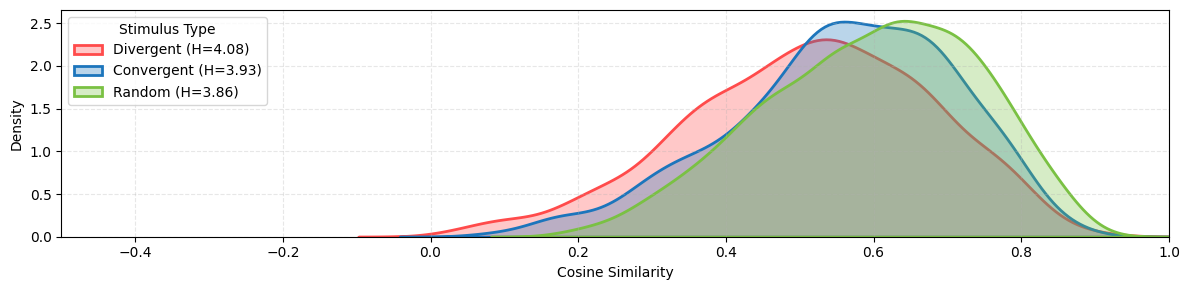

In [28]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import entropy

def analyze_rsm_and_entropy(X, labels, label_map, n_bins=50):
    """
    计算不同刺激条件下的RSM熵值和相似度分布
    """
    results = []
    rsm_dict = {}
    similarity_values_dict = {}

    print(f"{'Stimulus':<15} | {'Entropy (Bits)':<15} | {'Mean Similarity':<15} | {'Std Similarity':<15}")
    print("-" * 70)

    # 遍历每种刺激标签
    unique_labels = np.unique(labels)
    for label in unique_labels:
        name = label_map[label]
        
        # 1. 提取该条件下的数据
        mask = (labels == label)
        X_sub = X[mask]
        
        # 2. 计算 RSM (Cosine Similarity)
        # 结果是 (n_trials, n_trials) 的矩阵，范围 [-1, 1]
        rsm = cosine_similarity(X_sub)
        rsm_dict[name] = rsm
        
        # 3. 提取上三角非对角线元素 (Off-diagonal upper triangle)
        # k=1 表示不包含对角线。因为我们只关心试次间的变异，不关心试次和自己的相似度
        triu_indices = np.triu_indices_from(rsm, k=1)
        sim_values = rsm[triu_indices]
        similarity_values_dict[name] = sim_values
        
        # 4. 计算香农熵 (Shannon Entropy)
        # 先将连续的相似度值通过直方图转为概率分布
        # range=(-1, 1) 覆盖余弦相似度的理论范围
        counts, _ = np.histogram(sim_values, bins=n_bins, range=(-1, 1), density=True)
        
        # 归一化为概率 (加上极小值防止 log(0) 错误)
        probs = counts / np.sum(counts)
        ent = entropy(probs, base=2)  # base=2 单位为 bits
        
        # 记录统计量
        results.append({
            'Stimulus': name,
            'Entropy': ent,
            'Mean_Sim': np.mean(sim_values),
            'Std_Sim': np.std(sim_values)
        })
        
        print(f"{name:<15} | {ent:.4f}           | {np.mean(sim_values):.4f}          | {np.std(sim_values):.4f}")

    return pd.DataFrame(results), rsm_dict, similarity_values_dict


df_entropy, rsm_data, sim_values_data = analyze_rsm_and_entropy(
    X_trial_averaged_balanced, 
    labels_balanced, 
    label_names,
    n_bins=50 # 分箱数，可以根据数据量调整，通常 30-100 之间
)

# --- 可视化 1: 相似度分布直方图 (验证是否"变平"了) ---
plt.figure(figsize=(12, 3))
colors = {'Divergent': '#FF4B4B', 'Convergent': '#1C75BC', 'Random': '#7AC143', 'Resting': '#111111'}

for name, values in sim_values_data.items():
    sns.kdeplot(values, label=f"{name} (H={df_entropy[df_entropy['Stimulus']==name]['Entropy'].values[0]:.2f})", 
                color=colors[name], fill=True, alpha=0.3, linewidth=2)

# plt.title("Distribution of Pairwise Cosine Similarities (RSM Off-diagonal)")
plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.xlim(-0.5, 1.0) # 根据实际数据范围调整
plt.legend(title="Stimulus Type")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
save_path = os.path.join(fig_out_dir, "similarity_distribution.png")
plt.savefig(save_path, dpi=300)
plt.show()



In [29]:
# Experiment configuration
rr_neurons_spi = rr_selection_class(segments_spi, labels_spi)


使用快速RR筛选算法 (按类分别筛选取并集)...
  - 类别 1 贡献了 83 个 RR 神经元
  - 类别 2 贡献了 105 个 RR 神经元
  - 类别 3 贡献了 93 个 RR 神经元


In [30]:
rr_neurons_spi.keys()
rr_union = set.union(*rr_neurons_spi.values())
# rr_union

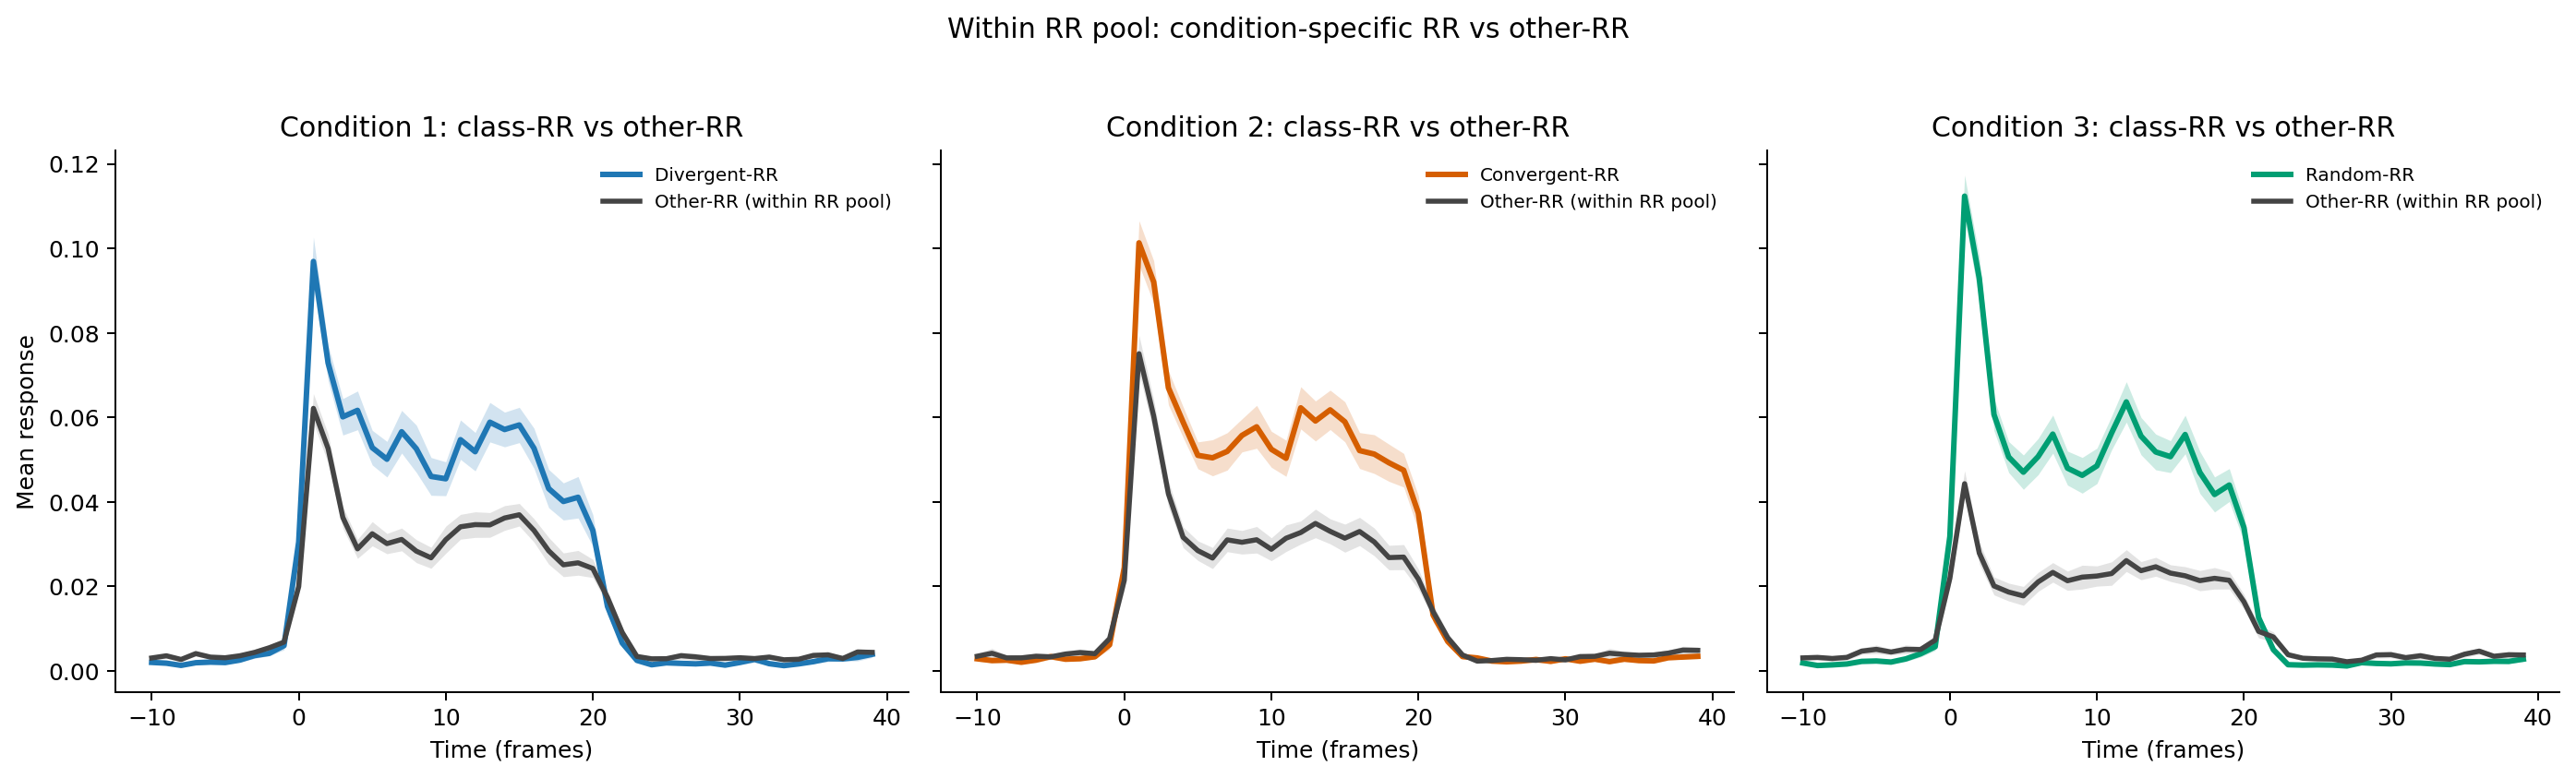

Participants (mean RR response at peak time / mean other-RR response at peak time):
Condition 1: 1.49
Condition 2: 1.39
Condition 3: 2.52


In [31]:
# Compare class-specific RR neurons with the remaining RR neurons inside the RR pool.
# This cell reuses rr_by_class / rr_union cached above and avoids recomputing RR sets.


# 定义语义映射
label_names = {1: 'Divergent', 2: 'Convergent', 3: 'Random'}

class_colors = {1: '#1F77B4', 2: '#D55E00', 3: '#009E73'}

participants = {}

def class_curve_and_sem(segments_group, labels, cls):
    cls_segments = segments_group[labels == cls]
    pop_mean = np.nanmean(cls_segments, axis=(0, 1))
    trial_means = np.nanmean(cls_segments, axis=1)
    pop_sem = stats.sem(trial_means, axis=0, nan_policy="omit")
    return pop_mean, pop_sem

def pop_curve_and_sem(trials_subset):
    # trials_subset: (n_trials, n_neurons_subset, n_time)
    m = np.nanmean(trials_subset, axis=(0, 1))
    trial_means = np.nanmean(trials_subset, axis=1)  # (n_trials, n_time)
    se = stats.sem(trial_means, axis=0, nan_policy='omit')
    return m, se


time_axis = np.arange(-10,40) # Assuming segments_spi has 50 frames from -10 to +39
fig, axes = plt.subplots(1, len(label_names), figsize=(5.2 * len(label_names), 4.5), dpi=180, sharey=True)
if len(label_names) == 1:
    axes = [axes]
    
for ax, cls in zip(axes, label_names.keys()):
    cls_trials = segments_spi[labels_spi == cls]
    rr_cls = rr_neurons_spi[cls]
    other_rr = rr_union - set(rr_cls)

    if len(rr_cls) == 0:
        ax.set_title(f'Class {cls}: no class-specific RR')
        ax.axis('off')
        continue

    m_rr, se_rr = pop_curve_and_sem(cls_trials[:, list(rr_cls), :])
    ax.plot(time_axis, m_rr, color=class_colors.get(cls, '#1F77B4'), lw=2.4, label=f'{label_names.get(cls, cls)}-RR')
    ax.fill_between(time_axis, m_rr - se_rr, m_rr + se_rr, color=class_colors.get(cls, '#1F77B4'), alpha=0.2, linewidth=0)

    if len(other_rr)     > 0:
        m_oth, se_oth = pop_curve_and_sem(cls_trials[:, list(other_rr), :])
        ax.plot(time_axis, m_oth, color='#444444', lw=2.2, label='Other-RR (within RR pool)')
        ax.fill_between(time_axis, m_oth - se_oth, m_oth + se_oth, color='#444444', alpha=0.15, linewidth=0)

    try:
        participants[cls] = np.mean(m_rr[10:13])/ np.mean(m_oth[10:13]) if len(other_rr) > 0 else np.mean(m_rr[10:13])
    except ZeroDivisionError:
        participants[cls] = 0
    ax.set_title(f'Condition {cls}: class-RR vs other-RR')
    ax.set_xlabel('Time (frames)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, fontsize=8)

axes[0].set_ylabel('Mean response')
fig.suptitle('Within RR pool: condition-specific RR vs other-RR', y=1.03)
fig.tight_layout()
plt.show()

print("Participants (mean RR response at peak time / mean other-RR response at peak time):")
for cls, value in participants.items():
    print(f"Condition {cls}: {value:.2f}")

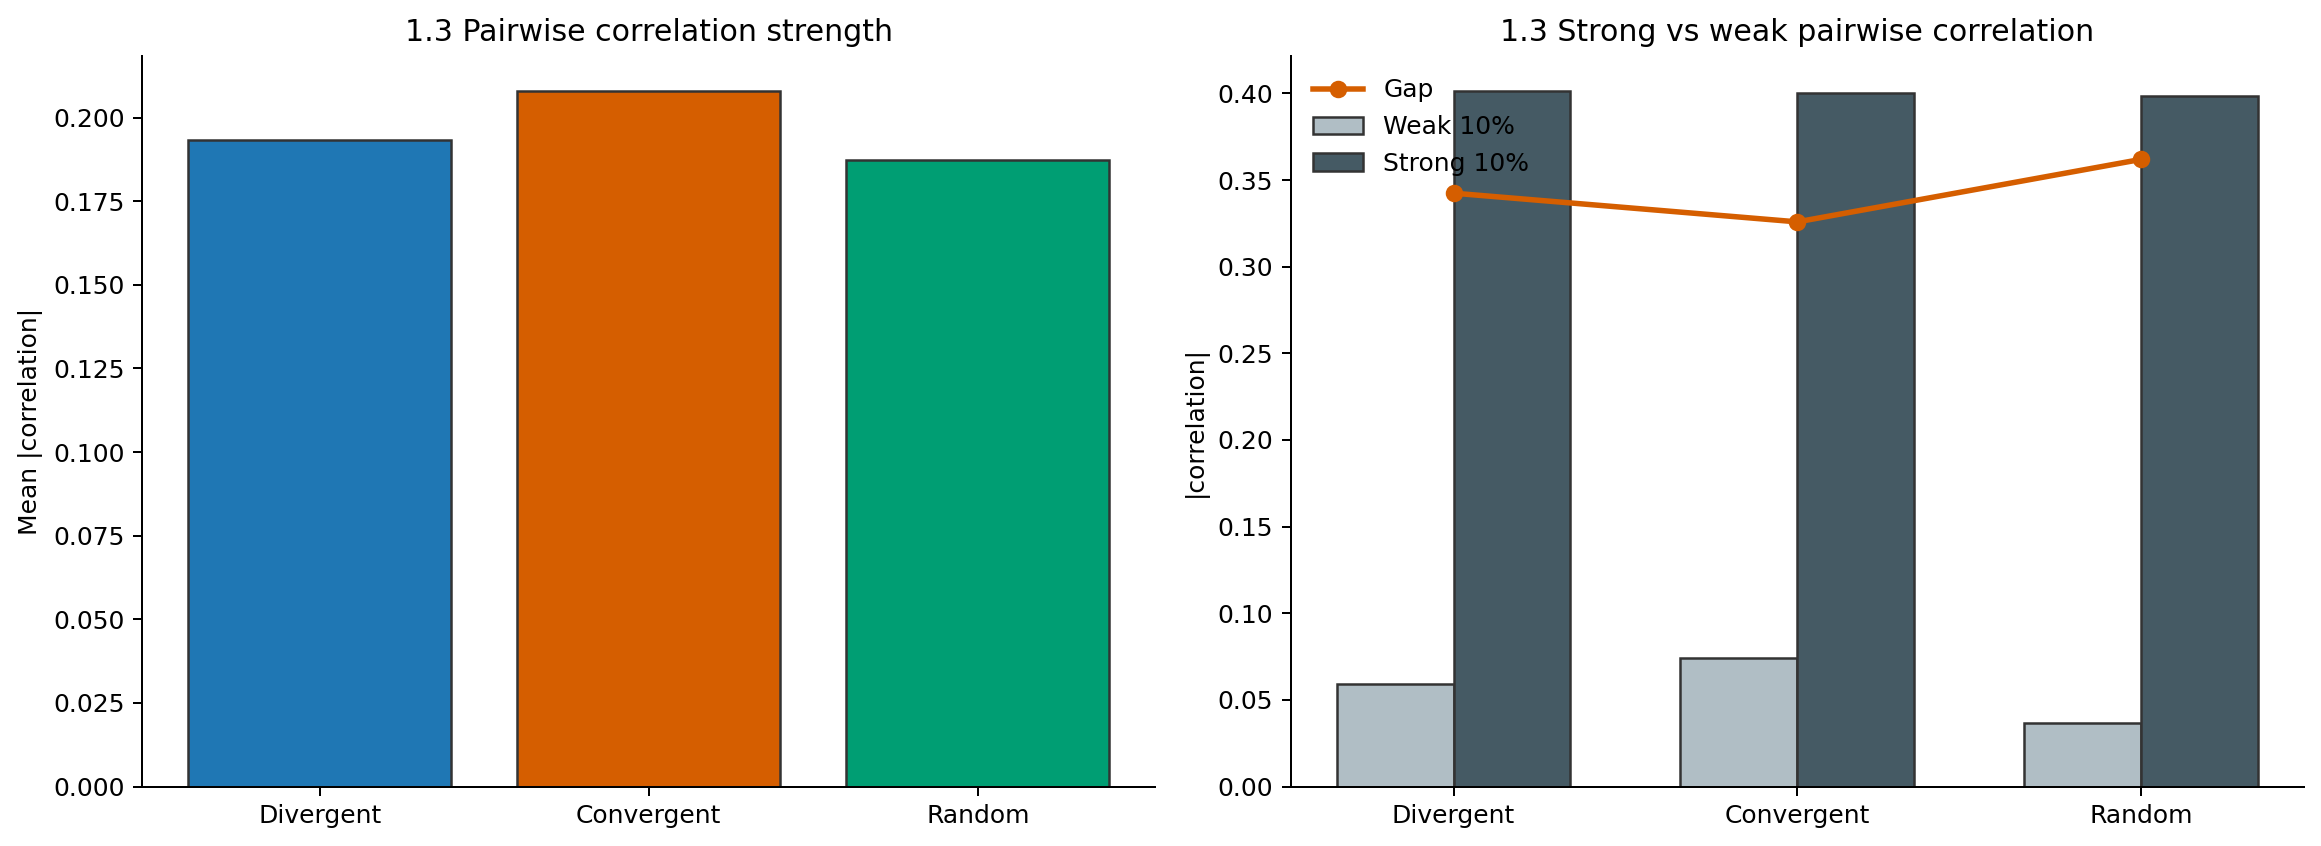

In [ ]:

strong_frac = 0.1
weak_frac = 0.1

def upper_triangle_values(matrix):
    mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)
    return matrix[mask]

corr_rows = []
for cls in sorted(nx_result):
    corr_matrix = np.asarray(nx_result[cls]["corr_matrix"], dtype=float)
    offdiag = upper_triangle_values(corr_matrix)
    abs_offdiag = offdiag
    if abs_offdiag.size == 0:
        continue
    rank_n_strong = max(1, int(np.floor(strong_frac * abs_offdiag.size)))
    rank_n_weak = max(1, int(np.floor(weak_frac * abs_offdiag.size)))
    sorted_abs = np.sort(abs_offdiag)
    weak_mean = float(np.mean(sorted_abs[:rank_n_weak]))
    strong_mean = float(np.mean(sorted_abs[-rank_n_strong:]))
    corr_rows.append({
        "Class_ID": cls,
        "Class_Name": label_names.get(cls, str(cls)),
        "Mean_Correlation": float(np.mean(offdiag)),
        "Mean_Abs_Correlation": float(np.mean(abs_offdiag)),
        "Weak_Abs_Correlation_Mean": weak_mean,
        "Strong_Abs_Correlation_Mean": strong_mean,
        "Strong_Weak_Gap": strong_mean - weak_mean,
        "Pair_Count": int(abs_offdiag.size),
    })
df_corr_strength = pd.DataFrame(corr_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), dpi=180)
axes[0].bar(
    df_corr_strength["Class_Name"],
    df_corr_strength["Mean_Abs_Correlation"],
    color=[class_colors[c] for c in df_corr_strength["Class_ID"]],
    edgecolor="#333333",
)
axes[0].set_ylabel("Mean |correlation|")
axes[0].set_title("1.3 Pairwise correlation strength")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

x = np.arange(len(df_corr_strength))
w = 0.34
axes[1].bar(x - w / 2, df_corr_strength["Weak_Abs_Correlation_Mean"], width=w, color="#B0BEC5", edgecolor="#333333", label="Weak 10%")
axes[1].bar(x + w / 2, df_corr_strength["Strong_Abs_Correlation_Mean"], width=w, color="#455A64", edgecolor="#333333", label="Strong 10%")
axes[1].plot(x, df_corr_strength["Strong_Weak_Gap"], color="#D55E00", lw=2.2, marker="o", label="Gap")
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_corr_strength["Class_Name"])
axes[1].set_ylabel("|correlation|")
axes[1].set_title("Strong vs weak pairwise correlation")
axes[1].legend(frameon=False)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join(fig_out_dir, f"pairwise_correlation.png"), dpi=300, bbox_inches="tight")
plt.show()